<a href="https://colab.research.google.com/github/dev-m0nk/KellySimulator/blob/main/KellySim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile kelly_simulator.cpp

#include <iostream>
#include <vector>
#include <random>
#include <cmath>
#include <fstream>
#include <algorithm>

using namespace std;

class Simulator
{
private:

    double initialBankroll;

    double winProbability;

    double odds;

    int numBets;

    default_random_engine gen;

public:

    Simulator(
        double bankroll,
        double p,
        double odds,
        int bets)
    {
        initialBankroll = bankroll;

        winProbability = p;

        this->odds = odds;

        numBets = bets;
    }

    double fixedFraction()
    {
        double bankroll =
            initialBankroll;

        bernoulli_distribution win(
            winProbability);
        vector<double> history;

        for(int i=0;i<numBets;i++)
        {
          history.push_back(bankroll);
            double bet =
                bankroll * 0.10;

            if(win(gen))
                bankroll += bet;
            else
                bankroll -= bet;

            if(bankroll <= 0)
                return 0;
        }
        ofstream file("fixed_curve.csv");

for(double b : history)
{
    file << b << "\n";
}

        return bankroll;
    }

    double aggressive()
    {
        double bankroll =
            initialBankroll;

        bernoulli_distribution win(
            winProbability);

        for(int i=0;i<numBets;i++)
        {
            double bet =
                bankroll * 0.25;

            if(win(gen))
                bankroll += bet;
            else
                bankroll -= bet;

            if(bankroll <= 0)
                return 0;
        }

        return bankroll;
    }

    double kelly()
    {
        double bankroll =
            initialBankroll;

        double b = odds - 1;

        double q =
            1 - winProbability;

        double fraction =
            ((b*winProbability)-q)
            / b;

        bernoulli_distribution win(
            winProbability);

        for(int i=0;i<numBets;i++)
        {
            double bet =
                bankroll * fraction;

            if(win(gen))
                bankroll += bet*b;
            else
                bankroll -= bet;

            if(bankroll <= 0)
                return 0;
        }

        return bankroll;
    }
};

int main()
{
    Simulator sim(
        10000,
        0.52,
        2.0,
        200);

    int runs = 1000;

    double fixedTotal = 0;
    double aggressiveTotal = 0;
    double kellyTotal = 0;

    int fixedRuin = 0;
    int aggressiveRuin = 0;
    int kellyRuin = 0;
    vector<double> fixedResults;
vector<double> aggressiveResults;
vector<double> kellyResults;

    for(int i=0;i<runs;i++)
    {
        double f =
            sim.fixedFraction();

        double a =
            sim.aggressive();

        double k =
            sim.kelly();

        fixedTotal += f;
        aggressiveTotal += a;
        kellyTotal += k;
        fixedResults.push_back(f);
aggressiveResults.push_back(a);
kellyResults.push_back(k);

        if(f == 0)
            fixedRuin++;

        if(a == 0)
            aggressiveRuin++;

        if(k == 0)
            kellyRuin++;
    }
    ofstream wealth("wealth.csv");

wealth << "Fixed,Aggressive,Kelly\n";

for(int i=0;i<runs;i++)
{
    wealth
    << fixedResults[i] << ","
    << aggressiveResults[i] << ","
    << kellyResults[i]
    << "\n";
}

wealth.close();
sort(
    fixedResults.begin(),
    fixedResults.end()
);

sort(
    aggressiveResults.begin(),
    aggressiveResults.end()
);

sort(
    kellyResults.begin(),
    kellyResults.end()
);

double fixedMedian =
    fixedResults[
        fixedResults.size()/2
    ];

double aggressiveMedian =
    aggressiveResults[
        aggressiveResults.size()/2
    ];

double kellyMedian =
    kellyResults[
        kellyResults.size()/2
    ];

    cout
    << "Average Final Bankroll\n\n";

    cout
    << "Fixed Fraction : "
    << fixedTotal/runs
    << endl;

    cout
    << "Aggressive     : "
    << aggressiveTotal/runs
    << endl;

    cout
    << "Kelly Criterion: "
    << kellyTotal/runs
    << endl;

    cout << "\n";

    cout
<< "Median Final Bankroll\n\n";

cout
<< "Fixed Fraction : "
<< fixedMedian
<< endl;

cout
<< "Aggressive     : "
<< aggressiveMedian
<< endl;

cout
<< "Kelly Criterion: "
<< kellyMedian
<< endl;

cout << "\n";

    cout
    << "Probability of Ruin\n\n";

    cout
    << "Fixed Fraction : "
    << (double)fixedRuin/runs
    << endl;

    cout
    << "Aggressive     : "
    << (double)aggressiveRuin/runs
    << endl;

    cout
    << "Kelly Criterion: "
    << (double)kellyRuin/runs
    << endl;
}

Overwriting kelly_simulator.cpp


In [ ]:
!g++ -std=c++17 kelly_simulator.cpp -o simulator

In [ ]:
!./simulator

Average Final Bankroll

Fixed Fraction : 21240.9
Aggressive     : 26720.9
Kelly Criterion: 13943.8

Median Final Bankroll

Fixed Fraction : 8168.08
Aggressive     : 121.485
Kelly Criterion: 11735.6

Probability of Ruin

Fixed Fraction : 0
Aggressive     : 0
Kelly Criterion: 0


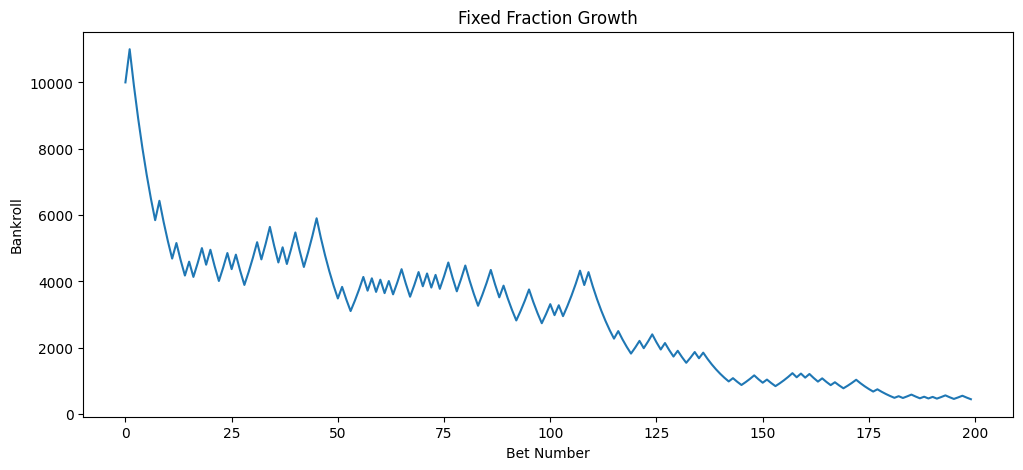

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "fixed_curve.csv",
    header=None
)

plt.figure(figsize=(12,5))
plt.plot(df[0])

plt.title(
    "Fixed Fraction Growth"
)

plt.xlabel("Bet Number")
plt.ylabel("Bankroll")

plt.show()

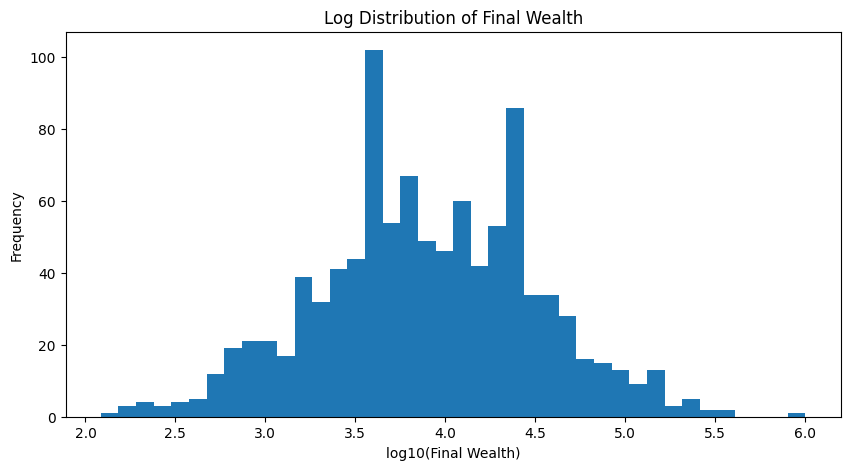

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("wealth.csv")

plt.figure(figsize=(10,5))

plt.hist(
    np.log10(df["Fixed"] + 1),
    bins=40
)

plt.title("Log Distribution of Final Wealth")
plt.xlabel("log10(Final Wealth)")
plt.ylabel("Frequency")

plt.show()

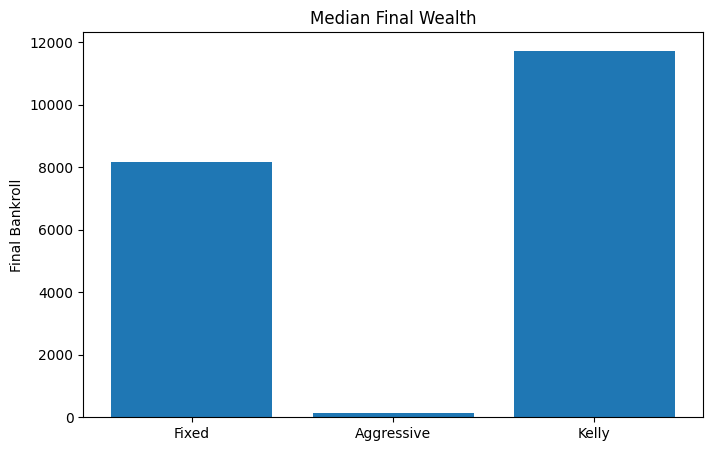

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wealth.csv")

strategies = [
    "Fixed",
    "Aggressive",
    "Kelly"
]

values = [
    df["Fixed"].median(),
    df["Aggressive"].median(),
    df["Kelly"].median()
]

plt.figure(figsize=(8,5))
plt.bar(strategies, values)

plt.title("Median Final Wealth")

plt.ylabel("Final Bankroll")

plt.show()